## Sentiment Analysis

### Load Data

In [3]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Read raw data
master_dir = os.path.dirname(os.getcwd())

processed_reviews = os.path.join(master_dir, "data", "processed_data", "feature_engineered_reviews.csv")

df_processed = pd.read_csv(processed_reviews)

df_processed.head()

,Review_ID,Review,Rating,Lemmatized_Tokens,Review_lemmatized,Platform,Restaurant,Sentiment_Label
0,R000001,food is taste good and the environment also no...,3.0,"['food', 'taste', 'good', 'environment', 'also...",food taste good environment also not bad . how...,Google,Tandoor Grill,Neutral
1,R000002,our family celebrated birthday on last weekend...,1.0,"['family', 'celebrate', 'birthday', 'last', 'w...",family celebrate birthday last weekend think 5...,Tripadvisor,Latest Recipe,Negative
2,R000003,pretty nice nonya food but very commercial alr...,3.0,"['pretty', 'nice', 'nonya', 'food', 'but', 've...",pretty nice nonya food but very commercial alr...,Google,Madam Kwan's Suria KLCC,Neutral
3,R000004,"food was not on point, the seafood was frozen,...",2.0,"['food', 'not', 'point', ',', 'seafood', 'froz...","food not point , seafood frozen , seasoning , ...",Google,Mercat Barcelona Gastrobar (1MontKiara),Negative
4,R000005,personaly for me is a big no....i saw flies la...,1.0,"['personaly', 'big', 'no', '....', 'saw', 'fly...",personaly big no .... saw fly lay egg fry chic...,Google,Restoran DEEN | Nasi Kandar,Negative


### Data Preparation

In [4]:
from sklearn.model_selection import train_test_split

# ============================================================
# 1. Prepare Binary Dataset
# ============================================================

# Remove neutral reviews (Rating = 3)
df_binary = df_processed[
    df_processed["Rating"] != 3
].copy()

# Create binary sentiment labels
# 0 = Negative (1–2 stars)
# 1 = Positive (4–5 stars)
df_binary["Binary_Sentiment"] = (
    df_binary["Rating"] >= 4
).astype(int)

print("Original class distribution:")
print(df_binary["Binary_Sentiment"].value_counts())

Original class distribution:
Binary_Sentiment
1    32204
0    32200
Name: count, dtype: int64


In [5]:
# remove duplicates
df_binary = df_binary.drop_duplicates(subset=["Review_lemmatized"])

In [6]:
# ============================================================
# 2. Train-Test Split
# ============================================================
# Split lemmatized AND raw in one call so rows stay aligned
(
    X_train_lem, X_test_lem,
    X_train_norm, X_test_norm,
    y_train, y_test
) = train_test_split(
    df_binary["Review_lemmatized"].values,
    df_binary["Review"].values,           # raw text, same rows
    df_binary["Binary_Sentiment"].values,
    test_size=0.2,
    random_state=42,
    stratify=df_binary["Binary_Sentiment"].values,
)

print("Training set:")
print(pd.Series(y_train).value_counts())

print("\nTest set:")
print(pd.Series(y_test).value_counts())

Training set:
1    24805
0    24687
Name: count, dtype: int64

Test set:
1    6201
0    6172
Name: count, dtype: int64


### BERT

I using pre-trained transformer model to inference the result because training a transformer model takes many days. It is eassy for me to just using pre-trained transformer model that only takes 30 minutes to predict the result.

In [50]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from tqdm import tqdm
from imblearn.over_sampling import RandomOverSampler

# 1. Setup GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # Must print 'cuda', NOT 'cpu'

Using device: cuda


In [51]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

CUDA available: True
Device count: 1


In [52]:
# 2. Load Model & Tokenizer with FP16 Precision
MODEL_NAME = "terrencewee12/xlm-roberta-base-sentiment-multilingual-finetuned-v3"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    torch_dtype=torch.float16
).to(device)
model.eval()

Invalid model-index. Not loading eval results into CardData.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [53]:
def predict_bert_multiclass(text_list, batch_size=64, max_len=256):
    probs_list = []
    with torch.no_grad():
        for i in tqdm(range(0, len(text_list), batch_size), desc="Inferring BERT"):
            batch_texts = list(text_list[i : i + batch_size])
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors="pt"
            ).to(device)

            outputs = model(**inputs)
            probabilities = torch.softmax(outputs.logits, dim=-1)
            probs_list.append(probabilities.cpu().numpy())
            
    return np.vstack(probs_list)

In [54]:
# 1. Map model dictionary indices dynamically
label2id = {v.lower(): k for k, v in model.config.id2label.items()}

print("id2label:", model.config.id2label)

neg_idx, pos_idx = 0, 2

id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [55]:
# Predict probabilities for the test set
bert_test_probs = predict_bert_multiclass(X_test_lem)

Inferring BERT: 100%|██████████| 194/194 [01:27<00:00,  2.22it/s]


In [56]:
binary_probs = bert_test_probs[:, [neg_idx, pos_idx]]

binary_probs_normalized = binary_probs / binary_probs.sum(axis=1, keepdims=True)

# Extract positive class probability (column index 1 in binary_probs_normalized)
bert_pred_proba = binary_probs_normalized[:, 1]

In [57]:
# After getting bert_pred_proba
from sklearn.metrics import f1_score

# Use a validation set (or a held-out portion of training data) to find optimal threshold
# Since you only have test set, you can split it or use the training set predictions
bert_train_probs = predict_bert_multiclass(X_train_lem)  # predict on training data
binary_train_probs = bert_train_probs[:, [neg_idx, pos_idx]]
binary_train_probs_normalized = binary_train_probs / binary_train_probs.sum(axis=1, keepdims=True)
bert_train_pred_proba = binary_train_probs_normalized[:, 1]

# Find best threshold on training data
thresholds = np.arange(0.3, 0.7, 0.01)
best_threshold, best_f1 = 0.5, 0
for t in thresholds:
    preds = (bert_train_pred_proba >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"Optimal threshold: {best_threshold:.2f} (train F1: {best_f1:.4f})")

# Apply to test set
bert_pred = (bert_pred_proba >= best_threshold).astype(int)

Inferring BERT: 100%|██████████| 774/774 [05:54<00:00,  2.18it/s]


Optimal threshold: 0.35 (train F1: 0.8816)


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# compute accuracy
bert_accuracy = accuracy_score(y_test, bert_pred)
bert_precision = precision_score(y_test, bert_pred, zero_division=0, average='macro')
bert_recall = recall_score(y_test, bert_pred, zero_division=0, average='macro')
bert_f1 = f1_score(y_test, bert_pred, zero_division=0, average='macro')
bert_roc_auc = roc_auc_score(y_test, bert_pred_proba, average='macro')

In [59]:
# print evaluation metrics
print('\n' + '='*70)
print('BERT EVALUATION (TEST SET)')
print('='*70)
print(f'Accuracy:  {bert_accuracy:.4f} | Precision: {bert_precision:.4f}')
print(f'Recall:    {bert_recall:.4f} | F1: {bert_f1:.4f} | ROC-AUC: {bert_roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, bert_pred, target_names=['Negative', 'Positive']))


BERT EVALUATION (TEST SET)
Accuracy:  0.8827 | Precision: 0.8829
Recall:    0.8827 | F1: 0.8827 | ROC-AUC: 0.9436

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      6172
    Positive       0.88      0.89      0.88      6201

    accuracy                           0.88     12373
   macro avg       0.88      0.88      0.88     12373
weighted avg       0.88      0.88      0.88     12373



## Comprehensive Sentiment Analysis: Three Approaches
### Lexicon-Based, Traditional ML, and Deep Learning (LSTM)

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import opinion_lexicon
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('vader_lexicon', quiet=True)
nltk.download('opinion_lexicon', quiet=True)

print('✓ All libraries imported')


✓ All libraries imported


## Part 1: Lexicon-Based Sentiment Analysis
### VADER and Opinion Lexicon (using normal reviews)

In [ ]:
# VADER Analysis
sia = SentimentIntensityAnalyzer()
vader_scores = [sia.polarity_scores(str(review)) for review in X_test_norm]
vader_df = pd.DataFrame(vader_scores)
vader_predictions = (vader_df['compound'] >= 0.05).astype(int)


VADER SENTIMENT ANALYSIS


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

print('\n' + '='*70)
print('VADER SENTIMENT ANALYSIS')
print('='*70)

vader_accuracy = accuracy_score(y_test, vader_predictions)
vader_precision = precision_score(y_test, vader_predictions, zero_division=0, average='macro')
vader_recall = recall_score(y_test, vader_predictions, zero_division=0, average='macro')
vader_f1 = f1_score(y_test, vader_predictions, zero_division=0, average='macro')
vader_roc_auc = roc_auc_score(y_test, vader_df["compound"].values)

print(f'Accuracy:  {vader_accuracy:.4f}')
print(f'Precision: {vader_precision:.4f}')
print(f'Recall:    {vader_recall:.4f}')
print(f'F1-Score:  {vader_f1:.4f}')
print(f'ROC-AUC:   {vader_roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, vader_predictions, target_names=['Negative', 'Positive']))


VADER SENTIMENT ANALYSIS
Accuracy:  0.7620
Precision: 0.7889
Recall:    0.7616
F1-Score:  0.7561
ROC-AUC:   0.8472

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.61      0.72      6172
    Positive       0.70      0.91      0.79      6201

    accuracy                           0.76     12373
   macro avg       0.79      0.76      0.76     12373
weighted avg       0.79      0.76      0.76     12373



In [62]:
# Opinion Lexicon Analysis
print('\n' + '='*70)
print('OPINION LEXICON SENTIMENT ANALYSIS')
print('='*70)

positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())

def count_sentiment_words(text):
    words = str(text).lower().split()
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    return pos - neg

opinion_scores = [count_sentiment_words(text) for text in X_test_lem]
opinion_predictions = (np.array(opinion_scores) > 0).astype(int)

opinion_accuracy = accuracy_score(y_test, opinion_predictions)
opinion_precision = precision_score(y_test, opinion_predictions, zero_division=0)
opinion_recall = recall_score(y_test, opinion_predictions, zero_division=0)
opinion_f1 = f1_score(y_test, opinion_predictions, zero_division=0)
opinion_roc_auc = roc_auc_score(y_test, np.array(opinion_scores))

print(f'Accuracy:  {opinion_accuracy:.4f}')
print(f'Precision: {opinion_precision:.4f}')
print(f'Recall:    {opinion_recall:.4f}')
print(f'F1-Score:  {opinion_f1:.4f}')
print(f'ROC-AUC:   {opinion_roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, opinion_predictions, target_names=['Negative', 'Positive']))



OPINION LEXICON SENTIMENT ANALYSIS
Accuracy:  0.7609
Precision: 0.7078
Recall:    0.8908
F1-Score:  0.7888
ROC-AUC:   0.8223

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.63      0.72      6172
    Positive       0.71      0.89      0.79      6201

    accuracy                           0.76     12373
   macro avg       0.78      0.76      0.76     12373
weighted avg       0.78      0.76      0.76     12373



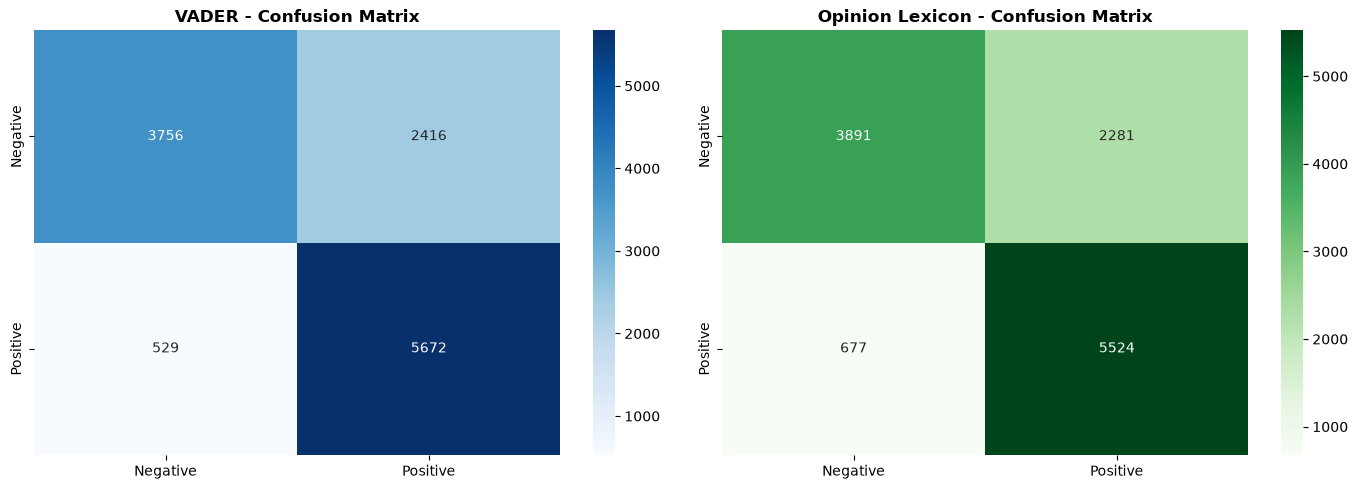

✓ Saved: ../outputs/01_lexicon_sentiment_analysis.png


In [63]:
# Visualize Lexicon Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vader_cm = confusion_matrix(y_test, vader_predictions)
sns.heatmap(vader_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title('VADER - Confusion Matrix', fontweight='bold')

opinion_cm = confusion_matrix(y_test, opinion_predictions)
sns.heatmap(opinion_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[1].set_title('Opinion Lexicon - Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/01_lexicon_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: ../outputs/01_lexicon_sentiment_analysis.png')


## Part 2: Traditional Machine Learning
### Logistic Regression, SVM, Random Forest (using lemmatized reviews)

In [ ]:
import joblib

## Part 2: Traditional Machine Learning
### Logistic Regression, SVM, Random Forest (using saved TF-IDF Vectorizer)
print('\n' + '='*70)
print('TRADITIONAL MACHINE LEARNING SENTIMENT ANALYSIS')
print('='*70)

# Load the fitted TF-IDF Vectorizer saved from Feature Engineering
vectorizer_path = '../data/processed_data/tfidf_vectorizer.pkl'
tfidf_vectorizer = joblib.load(vectorizer_path)
print(f"✓ Loaded TF-IDF Vectorizer from: {vectorizer_path}")

# Transform train and test text data using ONLY .transform()
# (Do NOT use fit_transform here to avoid data leakage and vocabulary mismatch)
X_train_tfidf = tfidf_vectorizer.transform(X_train_lem)
X_test_tfidf = tfidf_vectorizer.transform(X_test_lem)

print(f'TF-IDF train features shape: {X_train_tfidf.shape}')
print(f'TF-IDF test features shape:  {X_test_tfidf.shape}')


TRADITIONAL MACHINE LEARNING SENTIMENT ANALYSIS
TF-IDF features: (49492, 3000)


In [65]:
# Logistic Regression
print('\n' + '-'*70)
print('Logistic Regression')
print('-'*70)

lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred )
lr_precision = precision_score(y_test, lr_pred, average='macro')
lr_recall = recall_score(y_test, lr_pred, average='macro')
lr_f1 = f1_score(y_test, lr_pred, average='macro')
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba)

print(f'Accuracy: {lr_accuracy:.4f} | Precision: {lr_precision:.4f}')
print(f'Recall: {lr_recall:.4f} | F1: {lr_f1:.4f} | ROC-AUC: {lr_roc_auc:.4f}')



----------------------------------------------------------------------
Logistic Regression
----------------------------------------------------------------------


c:\Users\user\.conda\envs\restaurant_nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.9319 | Precision: 0.9320
Recall: 0.9320 | F1: 0.9319 | ROC-AUC: 0.9803


In [83]:
# Support Vector Machine
print('\n' + '-'*70)
print('Support Vector Machine (SVM)')
print('-'*70)

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC is significantly faster and optimized for TF-IDF text features
base_svc = LinearSVC(C=1.0, random_state=42)

# Wrap with CalibratedClassifierCV if probability scores are strictly needed
svm_model = CalibratedClassifierCV(base_svc, cv=5)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_pred_proba = svm_model.predict_proba(X_test_tfidf)[:, 1]

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='macro')
svm_recall = recall_score(y_test, svm_pred, average='macro')
svm_f1 = f1_score(y_test, svm_pred, average='macro')
svm_roc_auc = roc_auc_score(y_test, svm_pred_proba)

print(f'Accuracy: {svm_accuracy:.4f} | Precision: {svm_precision:.4f}')
print(f'Recall: {svm_recall:.4f} | F1: {svm_f1:.4f} | ROC-AUC: {svm_roc_auc:.4f}')



----------------------------------------------------------------------
Support Vector Machine (SVM)
----------------------------------------------------------------------
Accuracy: 0.9322 | Precision: 0.9322
Recall: 0.9322 | F1: 0.9322 | ROC-AUC: 0.9810


In [84]:
# Random Forest
print('\n' + '-'*70)
print('Random Forest')
print('-'*70)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)
rf_pred_proba = rf_model.predict_proba(X_test_tfidf)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='macro')
rf_recall = recall_score(y_test, rf_pred, average='macro')
rf_f1 = f1_score(y_test, rf_pred, average='macro')
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)

print(f'Accuracy: {rf_accuracy:.4f} | Precision: {rf_precision:.4f}')
print(f'Recall: {rf_recall:.4f} | F1: {rf_f1:.4f} | ROC-AUC: {rf_roc_auc:.4f}')



----------------------------------------------------------------------
Random Forest
----------------------------------------------------------------------
Accuracy: 0.8662 | Precision: 0.8669
Recall: 0.8662 | F1: 0.8662 | ROC-AUC: 0.9417


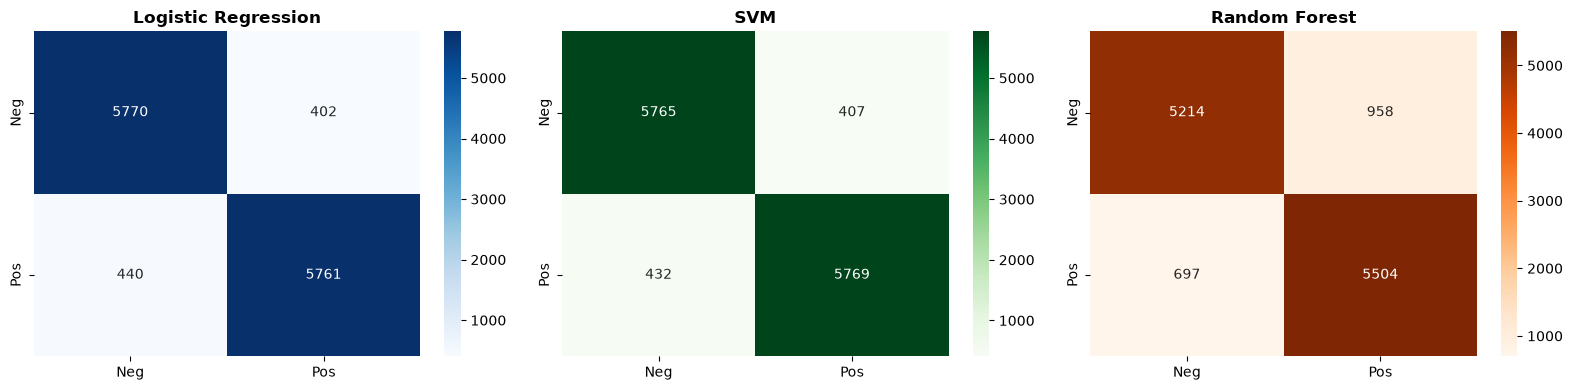

✓ Saved: ../outputs/02_traditional_ml_sentiment_analysis.png


In [68]:
# Visualize Traditional ML Results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lr_cm = confusion_matrix(y_test, lr_pred)
svm_cm = confusion_matrix(y_test, svm_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[0].set_title('Logistic Regression', fontweight='bold')

sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[1].set_title('SVM', fontweight='bold')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[2].set_title('Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_traditional_ml_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: ../outputs/02_traditional_ml_sentiment_analysis.png')


## Part 3: Deep Learning - LSTM
### Bidirectional LSTM (using lemmatized reviews)

In [69]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


In [70]:
print('\n' + '='*70)
print('DEEP LEARNING - LSTM SENTIMENT ANALYSIS')
print('='*70)

# Tokenization
max_words = 5000
max_len = 150
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_lem)

X_train_seq = tokenizer.texts_to_sequences(X_train_lem)
X_test_seq = tokenizer.texts_to_sequences(X_test_lem)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print(f'Sequences prepared: {X_train_pad.shape}')



DEEP LEARNING - LSTM SENTIMENT ANALYSIS
Sequences prepared: (49492, 150)


In [71]:
# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam',
                   metrics=['accuracy'])

print('Model Architecture:')
lstm_model.summary()


Model Architecture:


c:\Users\user\.conda\envs\restaurant_nlp\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
from sklearn.utils.class_weight import compute_class_weight

# Train LSTM
print('Training LSTM...')
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Pass it to fit()
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print('✓ LSTM training completed')


Training LSTM...
Epoch 1/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 136s 103ms/step - accuracy: 0.8930 - loss: 0.2662 - val_accuracy: 0.9201 - val_loss: 0.2215
Epoch 2/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 107s 86ms/step - accuracy: 0.9413 - loss: 0.1602 - val_accuracy: 0.9322 - val_loss: 0.1800
Epoch 3/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 121s 98ms/step - accuracy: 0.9528 - loss: 0.1312 - val_accuracy: 0.9334 - val_loss: 0.1913
Epoch 4/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 114s 92ms/step - accuracy: 0.9627 - loss: 0.1068 - val_accuracy: 0.9325 - val_loss: 0.1982
Epoch 5/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 108s 88ms/step - accuracy: 0.9704 - loss: 0.0876 - val_accuracy: 0.9302 - val_loss: 0.2320
✓ LSTM training completed


In [ ]:
# Evaluate LSTM
lstm_pred_proba = lstm_model.predict(X_test_pad, verbose=0)
lstm_pred = (lstm_pred_proba >= 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred, average='macro')
lstm_recall = recall_score(y_test, lstm_pred, average='macro')
lstm_f1 = f1_score(y_test, lstm_pred, average='macro')
lstm_roc_auc = roc_auc_score(y_test, lstm_pred_proba)

print('\n' + '='*70)
print('LSTM EVALUATION')
print('='*70)
print(f'Accuracy: {lstm_accuracy:.4f} | Precision: {lstm_precision:.4f}')
print(f'Recall: {lstm_recall:.4f} | F1: {lstm_f1:.4f} | ROC-AUC: {lstm_roc_auc:.4f}')



LSTM EVALUATION
Accuracy: 0.9284 | Precision: 0.9259
Recall: 0.9316 | F1: 0.9288 | ROC-AUC: 0.9808


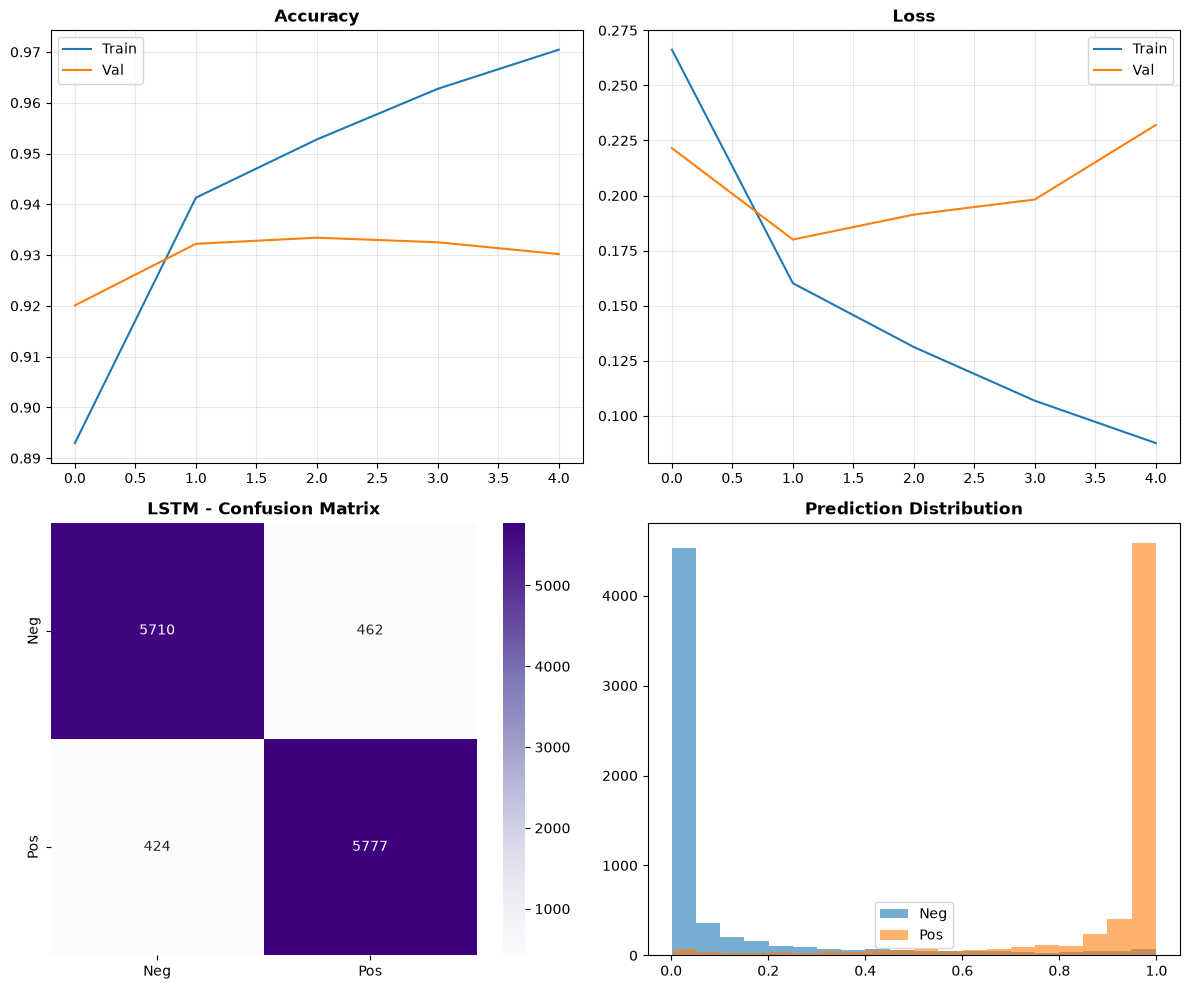

✓ Saved: ../outputs/03_lstm_sentiment_analysis.png


In [74]:
# Visualize LSTM Results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(history.history['accuracy'], label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Val')
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history.history['loss'], label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Val')
axes[0, 1].set_title('Loss', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

lstm_cm = confusion_matrix(y_test, lstm_pred)
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Purples', ax=axes[1, 0],
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[1, 0].set_title('LSTM - Confusion Matrix', fontweight='bold')

axes[1, 1].hist(lstm_pred_proba[y_test == 0], bins=20, alpha=0.6, label='Neg')
axes[1, 1].hist(lstm_pred_proba[y_test == 1], bins=20, alpha=0.6, label='Pos')
axes[1, 1].set_title('Prediction Distribution', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_lstm_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: ../outputs/03_lstm_sentiment_analysis.png')


### CNN

In [88]:
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, BatchNormalization,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_cnn(max_words, max_len, embed_dim=128,
              kernel_sizes=(3, 4, 5), num_filters=128,
              dropout=0.3):
    """Multi-kernel 1D CNN (Kim-style) for binary sentiment."""
    inp = Input(shape=(max_len,), dtype="int32", name="tokens")

    # Embedding (learned from scratch — same as your LSTM)
    x = Embedding(
        input_dim=max_words,
        output_dim=embed_dim,
        input_length=max_len,
        name="embedding",
    )(inp)

    # Parallel convolution branches with different receptive fields
    branches = []
    for k in kernel_sizes:
        b = Conv1D(
            filters=num_filters,
            kernel_size=k,
            padding="same",
            activation="relu",
            name=f"conv_{k}",
        )(x)
        b = GlobalMaxPooling1D(name=f"pool_{k}")(b)
        branches.append(b)

    # Concatenate all kernel features
    x = Concatenate(name="concat")(branches) if len(branches) > 1 else branches[0]

    # Classifier head
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(1, activation="sigmoid", name="sentiment")(x)

    model = Model(inp, out, name="TextCNN")
    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return model

cnn_model = build_cnn(max_words=max_words, max_len=max_len)
cnn_model.summary()

Model: "TextCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 150)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 128)  │    640,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 150, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 150, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 150, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5              │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_3[0][0],     │
│ (Concatenate)       │                   │            │ pool_4[0][0],     │
│                     │                   │            │ pool_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384)       │      1,536 │ concat[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 384)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     49,280 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment (Dense)   │ (None, 1)         │         65 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 896,129 (3.42 MB)

 Trainable params: 895,361 (3.42 MB)

 Non-trainable params: 768 (3.00 KB)

In [89]:
from sklearn.utils.class_weight import compute_class_weight

# Same class weights as LSTM (in case you added them)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    epochs=10,                       # same as LSTM
    batch_size=32,                   # same as LSTM
    validation_split=0.2,            # same as LSTM
    class_weight=class_weight_dict,  # same as LSTM (once you add it)
    callbacks=[early_stop],
    verbose=1,
)
print("✓ CNN training complete")

Class weights: {0: np.float64(1.0023899218212013), 1: np.float64(0.997621447288853)}
Epoch 1/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 189s 150ms/step - accuracy: 0.8958 - loss: 0.2551 - val_accuracy: 0.9382 - val_loss: 0.1718
Epoch 2/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9404 - loss: 0.1569 - val_accuracy: 0.9359 - val_loss: 0.1751
Epoch 3/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9536 - loss: 0.1233 - val_accuracy: 0.9325 - val_loss: 0.1849
Epoch 4/10
1238/1238 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.9643 - loss: 0.0955 - val_accuracy: 0.9297 - val_loss: 0.2064
✓ CNN training complete


In [90]:
# Evaluate CNN
cnn_pred_proba = cnn_model.predict(X_test_pad, verbose=0)
cnn_pred = (cnn_pred_proba >= 0.5).astype(int).flatten()

cnn_accuracy = accuracy_score(y_test, cnn_pred)
cnn_precision = precision_score(y_test, cnn_pred, average='macro')
cnn_recall = recall_score(y_test, cnn_pred, average='macro')
cnn_f1 = f1_score(y_test, cnn_pred, average='macro')
cnn_roc_auc = roc_auc_score(y_test, cnn_pred_proba)

print('\n' + '='*70)
print('CNN EVALUATION')
print('='*70)
print(f'Accuracy: {cnn_accuracy:.4f} | Precision: {cnn_precision:.4f}')
print(f'Recall: {cnn_recall:.4f} | F1: {cnn_f1:.4f} | ROC-AUC: {cnn_roc_auc:.4f}')



CNN EVALUATION
Accuracy: 0.9339 | Precision: 0.9341
Recall: 0.9339 | F1: 0.9339 | ROC-AUC: 0.9822


In [92]:
# Demonsstrate comparison of LSTM and CNN models
comparison_dl = pd.DataFrame({
    "Model":     ["LSTM", "CNN"],
    "Accuracy":  [accuracy_score(y_test, lstm_pred),  cnn_accuracy],
    "Precision": [precision_score(y_test, lstm_pred, zero_division=0),
                  cnn_precision],
    "Recall":    [recall_score(y_test, lstm_pred, zero_division=0),
                  cnn_recall],
    "F1 (mac)":  [lstm_f1, cnn_f1],
    "ROC-AUC":   [roc_auc_score(y_test, lstm_pred_proba),
                  cnn_roc_auc],
})

print(comparison_dl.round(4).to_string(index=False))

Model  Accuracy  Precision  Recall  F1 (mac)  ROC-AUC
 LSTM    0.9284     0.9259  0.9316    0.9288   0.9808
  CNN    0.9339     0.9341  0.9339    0.9339   0.9822


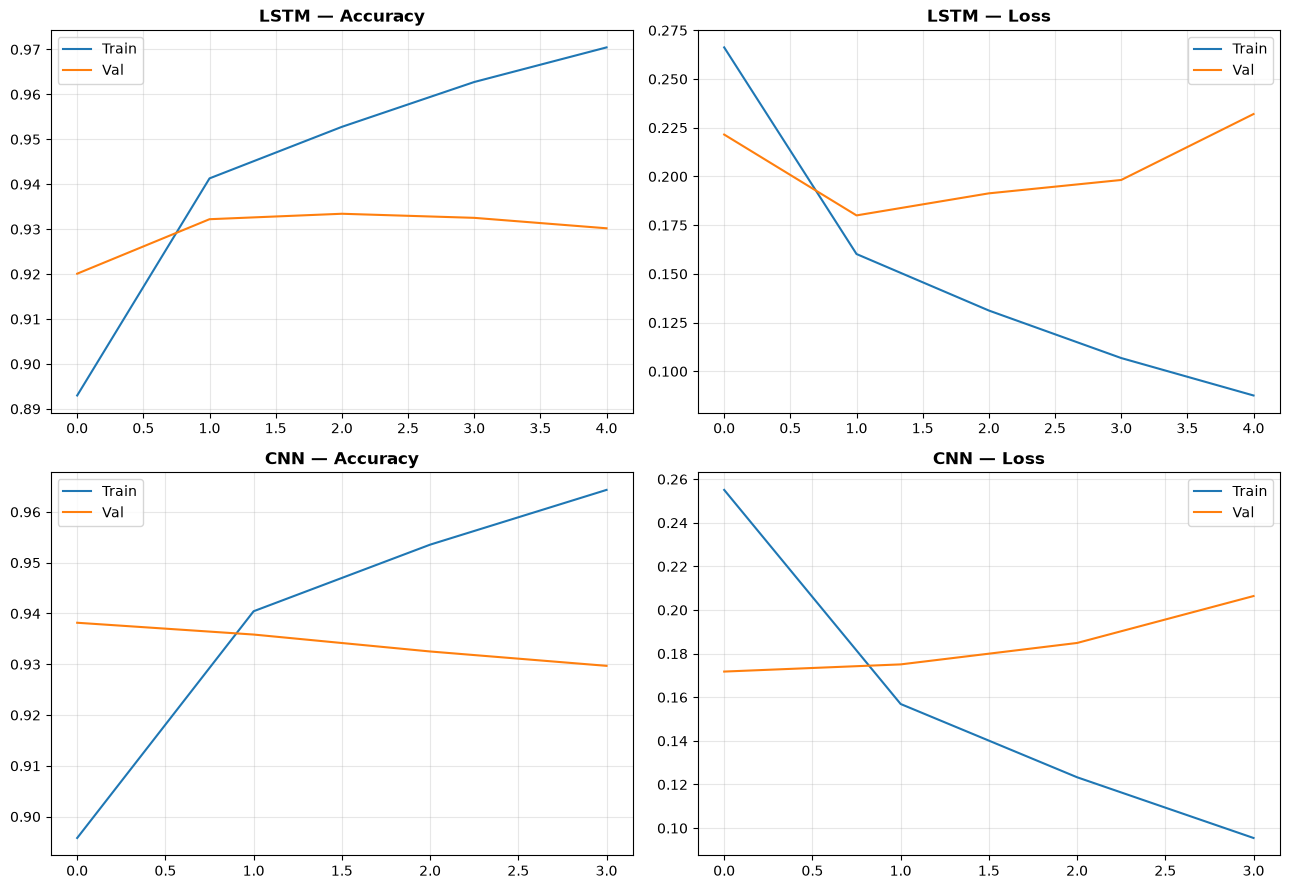

In [93]:
# Visualize Training Curves for LSTM and CNN
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (hist, name) in zip(
    axes,
    [(history, "LSTM"), (history_cnn, "CNN")],
):
    ax[0].plot(hist.history["accuracy"],     label="Train")
    ax[0].plot(hist.history["val_accuracy"], label="Val")
    ax[0].set_title(f"{name} — Accuracy", fontweight="bold")
    ax[0].legend(); ax[0].grid(alpha=0.3)

    ax[1].plot(hist.history["loss"],     label="Train")
    ax[1].plot(hist.history["val_loss"], label="Val")
    ax[1].set_title(f"{name} — Loss", fontweight="bold")
    ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/05_dl_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

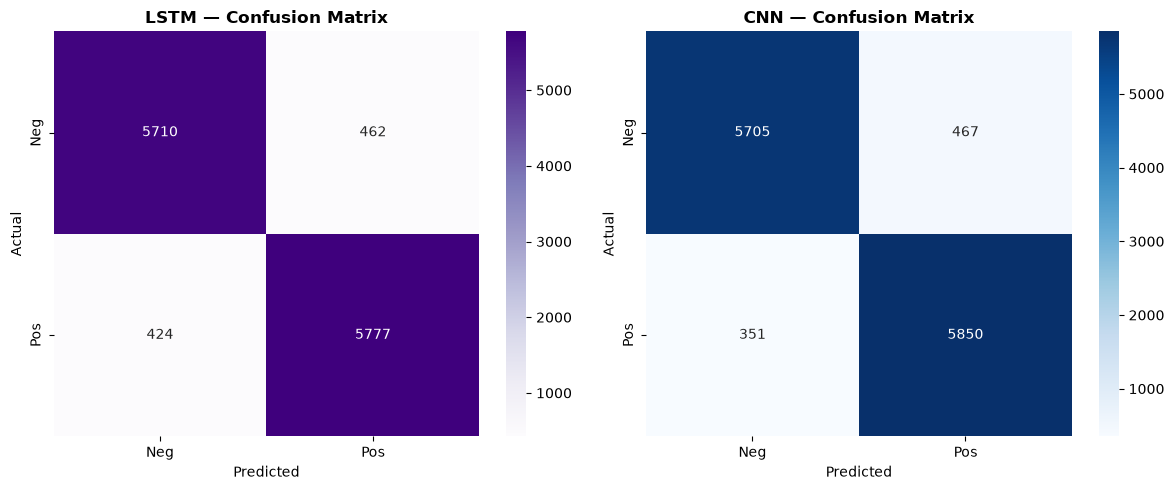

In [94]:
# Visualize Confusion Matrices for LSTM and CNN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (pred, name, cmap) in zip(
    axes,
    [(lstm_pred, "LSTM", "Purples"), (cnn_pred, "CNN", "Blues")],
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../outputs/06_dl_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

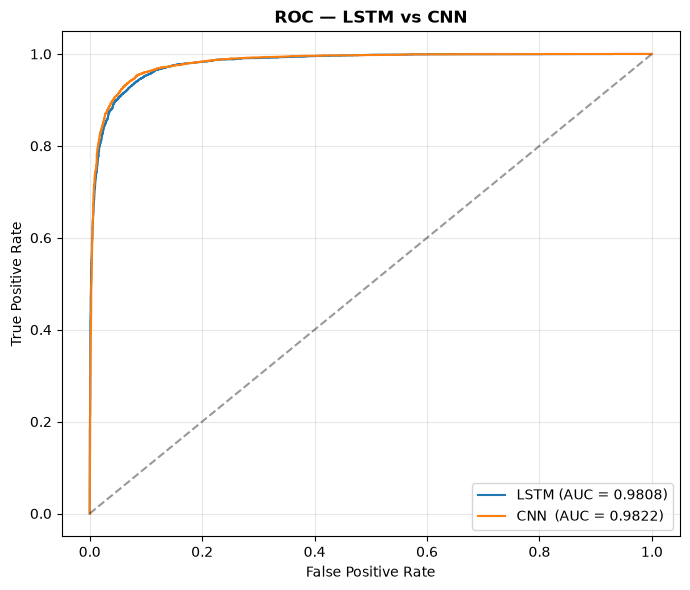

In [95]:
# Visualize ROC Curves for LSTM and CNN
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_pred_proba)
fpr_cnn,  tpr_cnn,  _ = roc_curve(y_test, cnn_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lstm, tpr_lstm,
         label=f"LSTM (AUC = {roc_auc_score(y_test, lstm_pred_proba):.4f})")
plt.plot(fpr_cnn, tpr_cnn,
         label=f"CNN  (AUC = {cnn_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — LSTM vs CNN", fontweight="bold")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/07_dl_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Comprehensive Comparison

In [96]:
# Create updated comprehensive comparison table including BERT
comparison = pd.DataFrame({
    'Method': [
        'VADER', 
        'Opinion Lexicon', 
        'Logistic Regression', 
        'SVM', 
        'Random Forest', 
        'LSTM', 
        'CNN',
        'BERT (XLM-RoBERTa)'
    ],
    'Accuracy': [vader_accuracy, opinion_accuracy, lr_accuracy, svm_accuracy, rf_accuracy, lstm_accuracy, cnn_accuracy, bert_accuracy],
    'Precision': [vader_precision, opinion_precision, lr_precision, svm_precision, rf_precision, lstm_precision, cnn_precision, bert_precision],
    'Recall': [vader_recall, opinion_recall, lr_recall, svm_recall, rf_recall, lstm_recall, cnn_recall, bert_recall],
    'F1-Score': [vader_f1, opinion_f1, lr_f1, svm_f1, rf_f1, lstm_f1, cnn_f1, bert_f1],
    'ROC-AUC': [np.nan, np.nan, lr_roc_auc, svm_roc_auc, rf_roc_auc, lstm_roc_auc, cnn_roc_auc, bert_roc_auc]
})

print('\n' + '='*90)
print('SENTIMENT ANALYSIS COMPARISON - ALL METHODS (INCLUDING BERT)')
print('='*90)
print(comparison.to_string(index=False))
print('\n' + '='*90)

comparison.to_csv('../outputs/sentiment_analysis_results_summary.csv', index=False)


SENTIMENT ANALYSIS COMPARISON - ALL METHODS (INCLUDING BERT)
             Method  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              VADER  0.761982   0.788916 0.761623  0.756134      NaN
    Opinion Lexicon  0.760931   0.707751 0.890824  0.788805      NaN
Logistic Regression  0.931949   0.931959 0.931955  0.931949 0.980262
                SVM  0.932191   0.932194 0.932195  0.932191 0.981008
      Random Forest  0.866241   0.866916 0.866191  0.866167 0.941680
               LSTM  0.928392   0.925950 0.931624  0.928778 0.980773
                CNN  0.933888   0.934057 0.933866  0.933879 0.982245
 BERT (XLM-RoBERTa)  0.882729   0.882897 0.882704  0.882710 0.943639



In [97]:
def overfit_report(name, model, X_train, y_train, X_test, y_test,
                   proba=True):
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    row = {
        "Model": name,
        "Train Acc": accuracy_score(y_train, train_pred),
        "Test Acc":  accuracy_score(y_test,  test_pred),
        "Train F1":  f1_score(y_train, train_pred),
        "Test F1":   f1_score(y_test,  test_pred),
    }
    row["Acc Gap"] = row["Train Acc"] - row["Test Acc"]
    row["F1 Gap"]  = row["Train F1"]  - row["Test F1"]

    if proba:
        row["Train AUC"] = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
        row["Test AUC"]  = roc_auc_score(y_test,  model.predict_proba(X_test)[:, 1])
        row["AUC Gap"]   = row["Train AUC"] - row["Test AUC"]
    return row

In [99]:
def gap_row(name, y_tr, y_te, tr_proba, te_proba, thr=0.5):
    tr_pred = (tr_proba >= thr).astype(int)
    te_pred = (te_proba >= thr).astype(int)
    row = {
        "Model": name,
        "Train Acc": accuracy_score(y_tr, tr_pred),
        "Test Acc":  accuracy_score(y_te, te_pred),
        "Train F1":  f1_score(y_tr, tr_pred),
        "Test F1":   f1_score(y_te, te_pred),
        "Train AUC": roc_auc_score(y_tr, tr_proba),
        "Test AUC":  roc_auc_score(y_te, te_proba),
    }
    row["Acc Gap"] = row["Train Acc"] - row["Test Acc"]
    row["F1 Gap"]  = row["Train F1"]  - row["Test F1"]
    row["AUC Gap"] = row["Train AUC"] - row["Test AUC"]
    return row

# sklearn models — reuse your existing overfit_report
rows = [
    overfit_report("LogReg", lr_model,  X_train_tfidf, y_train, X_test_tfidf, y_test),
    overfit_report("SVM",    svm_model, X_train_tfidf, y_train, X_test_tfidf, y_test),
    overfit_report("RF",     rf_model,  X_train_tfidf, y_train, X_test_tfidf, y_test),
]

# LSTM
lstm_tr = lstm_model.predict(X_train_pad, verbose=0).flatten()
lstm_te = lstm_model.predict(X_test_pad,  verbose=0).flatten()
rows.append(gap_row("LSTM", y_train, y_test, lstm_tr, lstm_te))

overfit_df = pd.DataFrame(rows)[[
    "Model", "Train Acc", "Test Acc", "Acc Gap",
    "Train F1", "Test F1", "F1 Gap",
    "Train AUC", "Test AUC", "AUC Gap",
]]

# CNN
cnn_tr = cnn_model.predict(X_train_pad, verbose=0).flatten()
cnn_te = cnn_model.predict(X_test_pad,  verbose=0).flatten()
rows.append(gap_row("CNN", y_train, y_test, cnn_tr, cnn_te))

overfit_df = pd.DataFrame(rows)[[
    "Model", "Train Acc", "Test Acc", "Acc Gap",
    "Train F1", "Test F1", "F1 Gap",
    "Train AUC", "Test AUC", "AUC Gap",
]]
print(overfit_df.round(4).to_string(index=False))

# gap 0 – 0.02 meaning the model is not overfitting, 0.02 – 0.05 mild overfitting, 0.05 – 0.1 moderate overfitting, >0.1 severe overfitting
# We can't BERT because we are doing inference on the test set, and we don't have training predictions for BERT in this notebook. To evaluate BERT's overfitting, we would need to run predictions on the training set as well, which is not included here.

 Model  Train Acc  Test Acc  Acc Gap  Train F1  Test F1  F1 Gap  Train AUC  Test AUC  AUC Gap
LogReg     0.9429    0.9319   0.0109    0.9429   0.9319  0.0110     0.9845    0.9803   0.0043
   SVM     0.9509    0.9322   0.0188    0.9510   0.9322  0.0188     0.9887    0.9810   0.0077
    RF     0.8861    0.8662   0.0198    0.8897   0.8693  0.0204     0.9590    0.9417   0.0173
  LSTM     0.9548    0.9284   0.0264    0.9551   0.9288  0.0263     0.9895    0.9808   0.0087
   CNN     0.9556    0.9339   0.0217    0.9562   0.9347  0.0215     0.9907    0.9822   0.0084


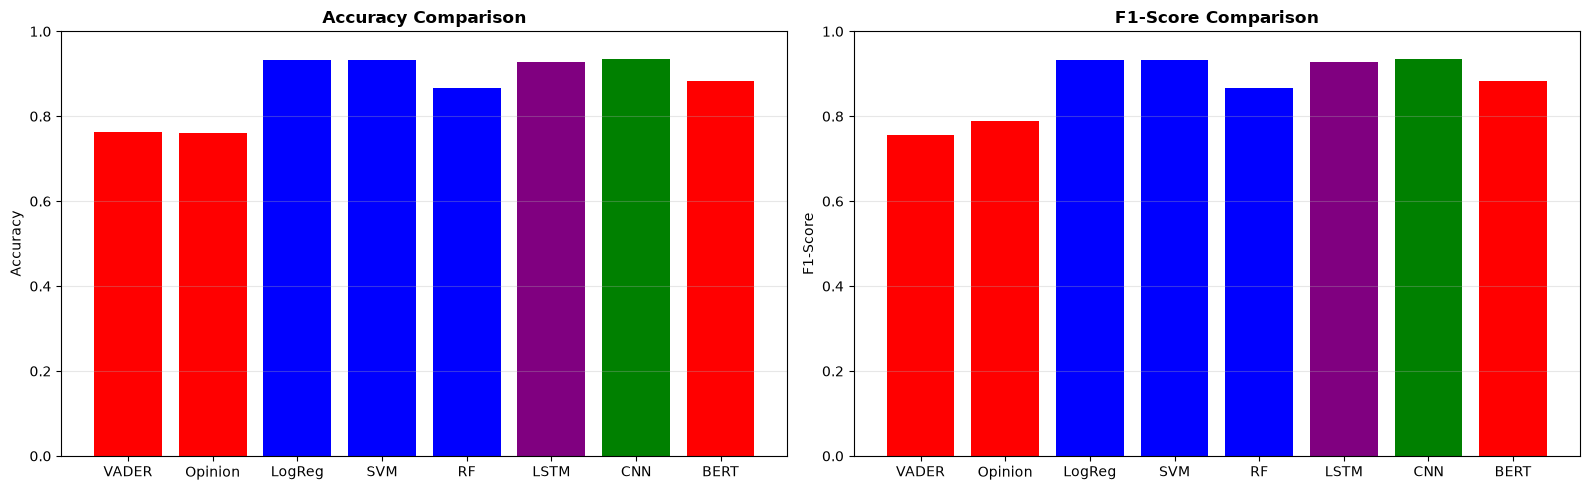


Best Overall: CNN
  F1-Score: 0.9339


In [100]:
# Final comparison bar chart visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

methods = ['VADER', 'Opinion', 'LogReg', 'SVM', 'RF', 'LSTM', 'CNN', 'BERT']
accuracy = comparison['Accuracy'].tolist()
f1 = comparison['F1-Score'].tolist()

colors = ['red']*2 + ['blue']*3 + ['purple'] + ['green']

axes[0].bar(methods, accuracy, color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(methods, f1, color=colors)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score Comparison', fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_sentiment_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nBest Overall: {comparison.loc[comparison["F1-Score"].idxmax(), "Method"]}')
print(f'  F1-Score: {comparison["F1-Score"].max():.4f}')